Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
10 odors tested
20 odors tested
30 odors tested
40 odors tested
50 odors tested
60 odors tested
70 odors tested
80 odors tested
90 odors tested
Simulation Duration = 1076.82400012s


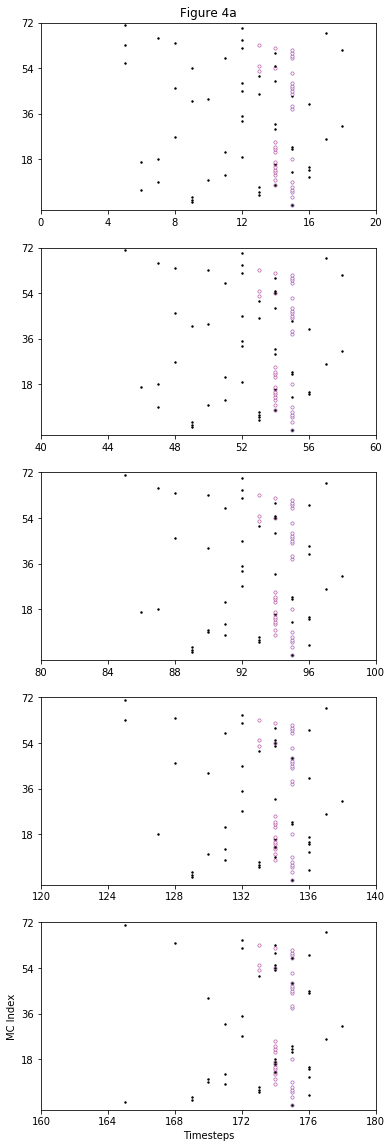

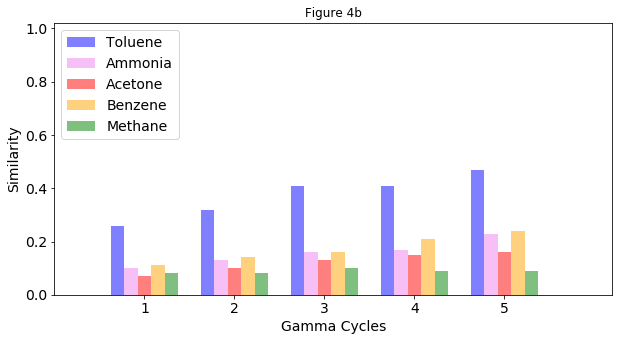

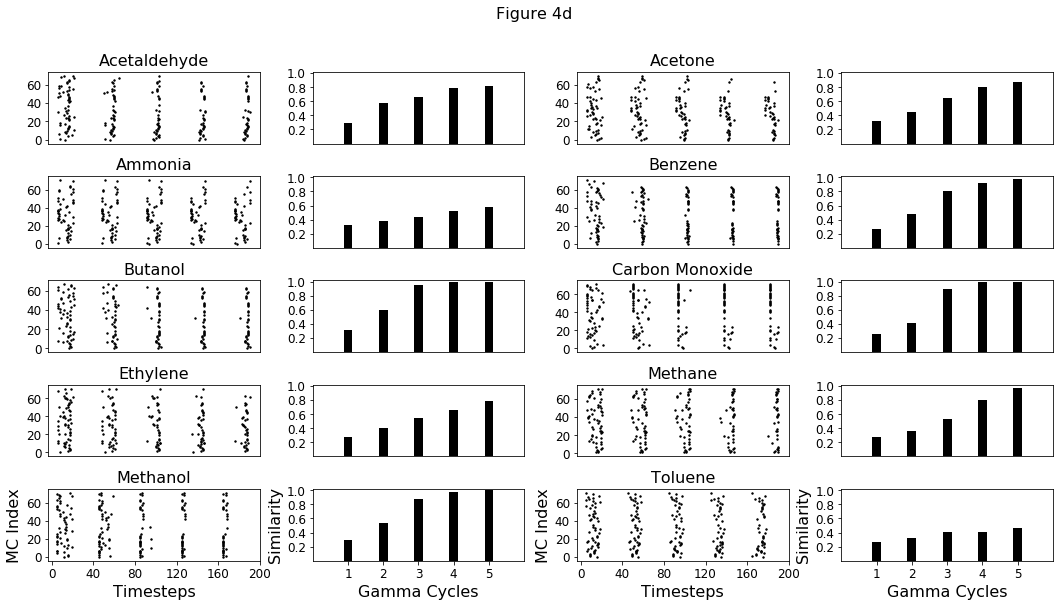

In [15]:
from lib import epl 
from my_lib import my_readout
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 

#Load Data
rf = open('./data/multiOdorTest.pi', 'r');
trainingOdors = np.array(pickle.load(rf));
testOdors = np.array(pickle.load(rf));
rf.close();

#trainingOdors, testOdors = np.load('multiOdorTest.npy', fix_imports=True, allow_pickle=True); 

nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1); #I assume each call of sniff adds 5 lists ("rows") to epl.gammaCode
    epl.GClayer.invokeNeurogenesis();
    #add another for loop
    #we added this loop
for i in range(0, len(trainingOdors)):
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
my_sMatrix = my_readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  

#Plots
plots.plotFigure4a(epl.gammaCode); 
plots.plotFigure4b(my_sMatrix); 
plots.plotFigure4d(epl.gammaCode, my_sMatrix); 

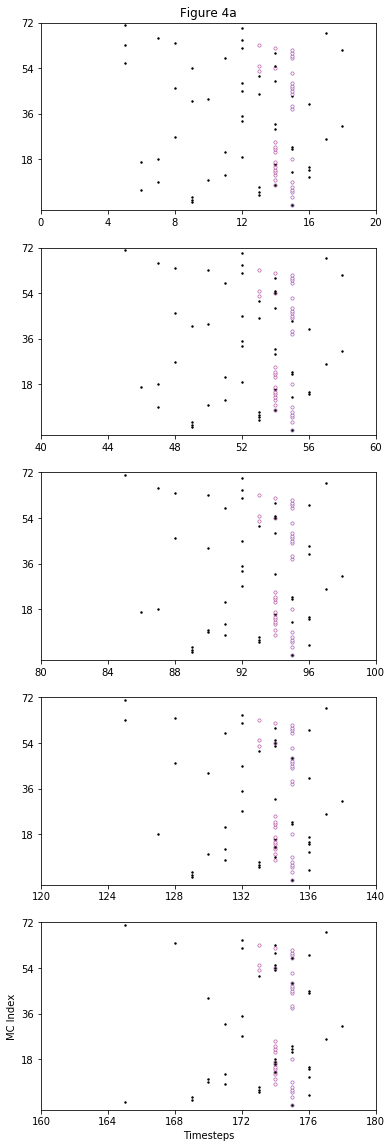

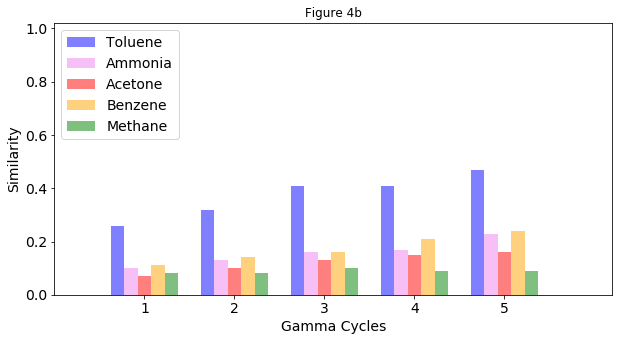

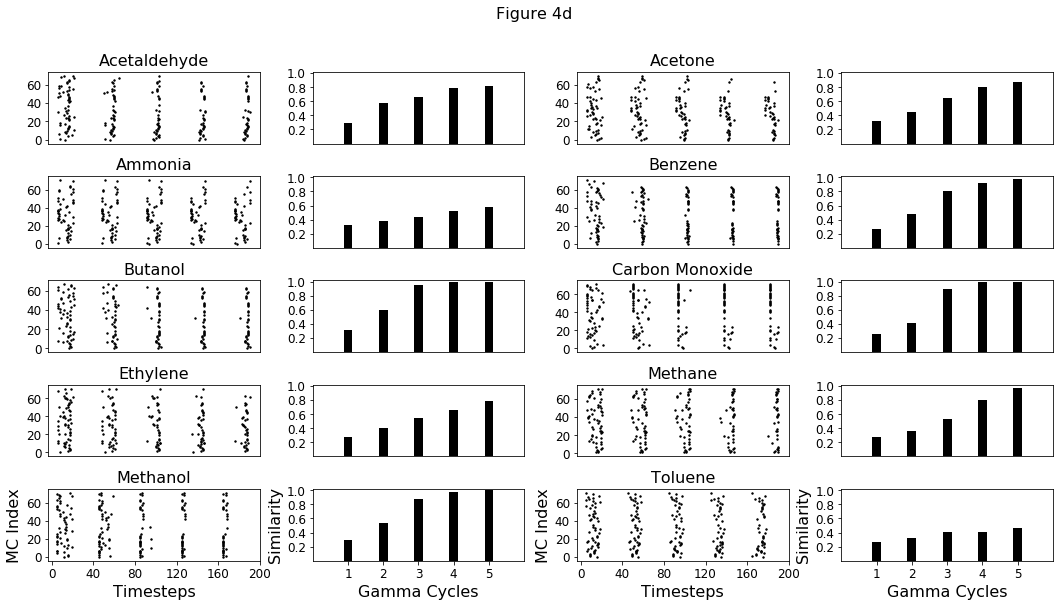

In [16]:
plots.plotFigure4a(epl.gammaCode); 
plots.plotFigure4b(my_sMatrix); 
plots.plotFigure4d(epl.gammaCode, my_sMatrix); 

In [23]:
epl.gammaCode[168]

[5,
 0,
 0,
 5,
 0,
 5,
 5,
 5,
 6,
 5,
 6,
 0,
 6,
 6,
 5,
 6,
 6,
 6,
 5,
 0,
 0,
 6,
 6,
 6,
 0,
 6,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 5,
 5,
 0,
 0,
 0,
 0,
 5,
 5,
 5,
 5,
 5,
 0,
 0,
 0,
 5,
 7,
 6,
 7,
 0,
 0,
 5,
 5,
 5,
 5,
 6,
 7,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [24]:
my_gammaCode = epl.gammaCode

In [25]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import time
import pickle 

#Load Data
rf = open('./data/multiOdorTest.pi', 'r');
trainingOdors = np.array(pickle.load(rf));
testOdors = np.array(pickle.load(rf));
rf.close();
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor) 

Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
10 odors tested
20 odors tested
30 odors tested
40 odors tested
50 odors tested
60 odors tested
70 odors tested
80 odors tested
90 odors tested
Simulation Duration = 1120.5769999s


In [12]:
my_sMatrix == sMatrix

False

In [13]:
my_sMatrix

[[0.25, 0.11, 0.08, 0.09, 0.1, 0.07, 0.14, 0.13, 0.15, 0.08],
 [0.31, 0.13, 0.08, 0.09, 0.12, 0.1, 0.18, 0.16, 0.19, 0.09],
 [0.38, 0.18, 0.09, 0.09, 0.14, 0.14, 0.21, 0.19, 0.25, 0.1],
 [0.5, 0.24, 0.11, 0.1, 0.18, 0.17, 0.27, 0.24, 0.36, 0.14],
 [0.5, 0.22, 0.08, 0.07, 0.18, 0.17, 0.24, 0.2, 0.38, 0.16],
 [0.29, 0.11, 0.07, 0.07, 0.11, 0.09, 0.2, 0.11, 0.14, 0.09],
 [0.47, 0.17, 0.1, 0.09, 0.15, 0.13, 0.27, 0.18, 0.2, 0.13],
 [0.6, 0.19, 0.11, 0.08, 0.2, 0.17, 0.3, 0.2, 0.23, 0.15],
 [0.73, 0.22, 0.12, 0.09, 0.25, 0.22, 0.35, 0.24, 0.31, 0.2],
 [0.76, 0.24, 0.12, 0.09, 0.25, 0.22, 0.35, 0.24, 0.35, 0.2],
 [0.29, 0.08, 0.05, 0.04, 0.11, 0.1, 0.12, 0.11, 0.13, 0.06],
 [0.53, 0.18, 0.1, 0.08, 0.17, 0.14, 0.23, 0.19, 0.24, 0.14],
 [0.82, 0.22, 0.11, 0.09, 0.25, 0.2, 0.33, 0.23, 0.31, 0.16],
 [0.97, 0.27, 0.12, 0.1, 0.3, 0.24, 0.41, 0.26, 0.32, 0.19],
 [0.97, 0.27, 0.12, 0.1, 0.3, 0.24, 0.41, 0.26, 0.32, 0.19],
 [0.29, 0.13, 0.06, 0.07, 0.1, 0.09, 0.16, 0.14, 0.15, 0.13],
 [0.37, 0.14, 0.

In [14]:
sMatrix

[[0.26, 0.11, 0.08, 0.09, 0.1, 0.07, 0.14, 0.13, 0.15, 0.08],
 [0.38, 0.14, 0.1, 0.1, 0.15, 0.12, 0.19, 0.16, 0.21, 0.12],
 [0.53, 0.2, 0.09, 0.07, 0.2, 0.17, 0.24, 0.17, 0.26, 0.14],
 [0.8, 0.24, 0.13, 0.1, 0.26, 0.21, 0.32, 0.22, 0.3, 0.18],
 [0.97, 0.27, 0.13, 0.1, 0.31, 0.25, 0.38, 0.26, 0.36, 0.2],
 [0.3, 0.11, 0.07, 0.07, 0.11, 0.09, 0.2, 0.11, 0.14, 0.09],
 [0.6, 0.2, 0.12, 0.09, 0.17, 0.16, 0.29, 0.19, 0.25, 0.13],
 [0.87, 0.29, 0.13, 0.11, 0.29, 0.22, 0.38, 0.26, 0.37, 0.2],
 [0.89, 0.29, 0.13, 0.11, 0.3, 0.24, 0.38, 0.27, 0.36, 0.21],
 [0.92, 0.25, 0.12, 0.09, 0.3, 0.23, 0.37, 0.24, 0.35, 0.19],
 [0.3, 0.08, 0.05, 0.04, 0.11, 0.1, 0.12, 0.11, 0.13, 0.06],
 [0.52, 0.17, 0.09, 0.07, 0.21, 0.19, 0.25, 0.18, 0.22, 0.14],
 [0.67, 0.2, 0.11, 0.08, 0.21, 0.17, 0.29, 0.2, 0.27, 0.16],
 [0.82, 0.23, 0.11, 0.08, 0.29, 0.21, 0.37, 0.23, 0.32, 0.19],
 [0.92, 0.26, 0.13, 0.1, 0.31, 0.24, 0.36, 0.26, 0.35, 0.2],
 [0.29, 0.13, 0.06, 0.07, 0.1, 0.09, 0.16, 0.14, 0.15, 0.13],
 [0.41, 0.16, 0.

In [28]:
indices = []
for i in range(0,10):
    indices.append(range(10*i,10*i+5))
my_gammaCode[0:50] == epl.gammaCode[i in indices]

False